# Assignment 4

# Breast Cancer Classification using K-Nearest Neighbors (KNN)

## AI/ML Internship

**Name:** Khushie Brahma

**Assignment Number:** Assignment 4

## Objective

The objective of this project is to develop a K-Nearest Neighbors (KNN) classification model to predict whether a breast tumor is **Malignant (M)** or **Benign (B)** based on diagnostic measurements. The model will be trained, evaluated, and analyzed using standard classification metrics.

## 1: Import Required Libraries

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2: Load the Dataset

In [29]:
df = pd.read_csv("../data/data.csv")

## 3: Display the First Five Records

In [30]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## 4: Dataset Information

In [31]:
print("Shape of Dataset:", df.shape)

print("\nDataset Information:")
df.info()

Shape of Dataset: (569, 33)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 n

In [32]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## 5: Identify Features

In [33]:
# Identifing numerical features

numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nTarget Variable:")
print("diagnosis")

Numerical Features:
['id', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

Target Variable:
diagnosis


### Observation

The dataset contains multiple numerical features extracted from breast tumor measurements. The target variable is **diagnosis**, where **M** represents a malignant tumor and **B** represents a benign tumor. These numerical features will be used to train the K-Nearest Neighbors (KNN) classification model.

## 6: Data Preprocessing

### 6.1 Check for Missing Values

In [34]:
# Checking for missing values

df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

### Observation

The dataset does not contain missing values in the useful features. The **Unnamed: 32** column contains only null values and will be removed because it does not contribute to model training.

### 6.2 Remove Unnecessary Columns

In [35]:
# Removing unnecessary columns

df = df.drop(columns=["id", "Unnamed: 32"])

In [36]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 6.3 Encode the Target Variable

In [37]:
# Encoding diagnosis

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

In [38]:
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

### Observation

The target variable was encoded into numerical values, where **Malignant (M)** was converted to **1** and **Benign (B)** was converted to **0**.

### 6.4 Select Features and Target Variable

In [39]:
# Separating features and target

X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

In [40]:
print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

Feature Shape: (569, 30)
Target Shape : (569,)


### 6.5 Split the Dataset

In [41]:
# Spliting dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### 6.6 Standardize the Features

In [42]:
# Standardizing features

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [43]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (455, 30)
Testing Features : (114, 30)
Training Labels  : (455,)
Testing Labels   : (114,)


### Observation

The dataset was successfully preprocessed by removing unnecessary columns, encoding the target variable, standardizing the feature values, and splitting the dataset into **80% training** and **20% testing** sets. Feature scaling is particularly important for KNN because it relies on distance calculations to classify data points.

## 7: Model Development

### 7.1 Train the K-Nearest Neighbors (KNN) Classifier

In [44]:
# Creating the KNN classifier

knn = KNeighborsClassifier(n_neighbors=5)

In [45]:
# Training the KNN classifier

knn.fit(X_train, y_train)

KNeighborsClassifier()

### Observation

The K-Nearest Neighbors (KNN) classifier was successfully trained using the training dataset with **K = 5**, as specified in the assignment.

### 7.2 Predict the Test Dataset

In [46]:
# Predicting class labels

y_pred = knn.predict(X_test)

In [47]:
# Comparing Actual vs Predicted Labels

comparison = pd.DataFrame({
    "Actual Diagnosis": y_test.values,
    "Predicted Diagnosis": y_pred
})

comparison.head(10)

,Actual Diagnosis,Predicted Diagnosis
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,1,1
6,1,1
7,1,1
8,0,1
9,0,0


In [48]:
comparison.style.hide(axis="index")

Actual Diagnosis,Predicted Diagnosis
0,0
1,1
1,1
0,0
0,0
1,1
1,1
1,1
0,1
0,0


### Observation

The trained KNN classifier successfully predicted the class labels for the testing dataset. The comparison between the actual and predicted diagnoses indicates that the model performs well in distinguishing between malignant and benign tumors.

## 8: Model Evaluation

### 8.1 Evaluate the Model

In [49]:
# Calculating evaluation metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy Score :", round(accuracy, 4))
print("Precision      :", round(precision, 4))
print("Recall         :", round(recall, 4))
print("F1-Score       :", round(f1, 4))

Accuracy Score : 0.9474
Precision      : 0.9302
Recall         : 0.9302
F1-Score       : 0.9302


### 8.2 Confusion Matrix

<Figure size 600x500 with 0 Axes>

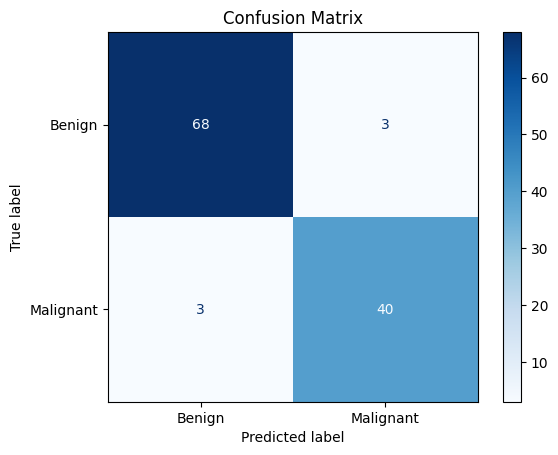

In [50]:
# Generating confusion matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "../images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 8.3 Model Performance Observations

### Observations

1. The K-Nearest Neighbors (KNN) classifier achieved a high accuracy score, indicating that it effectively classified breast tumors as malignant or benign.

2. The precision, recall, and F1-score demonstrate that the model performs well in identifying malignant tumors while minimizing incorrect classifications.

3. The confusion matrix shows that most test samples were classified correctly, indicating that KNN is a suitable algorithm for this breast cancer classification problem.

## 9: Conclusion

### Conclusion

This project successfully developed a K-Nearest Neighbors (KNN) classification model to predict whether a breast tumor is malignant or benign using diagnostic measurements. After preprocessing the data through feature scaling and training the model with **K = 5**, the classifier achieved high accuracy and performed well across precision, recall, and F1-score metrics. The confusion matrix further demonstrated that most tumors were classified correctly. Feature scaling played a crucial role because KNN is a distance-based algorithm, and scaling ensures that all features contribute equally to distance calculations. One limitation of KNN is that it can become computationally expensive when working with large datasets, as it calculates distances to all training samples during prediction. Overall, KNN proved to be an effective classification algorithm for this dataset.